Model Evaluation Results:
Mean Absolute Error (MAE): rupees 4,212.13
Root Mean Squared Error (RMSE): rupees 5,338.64


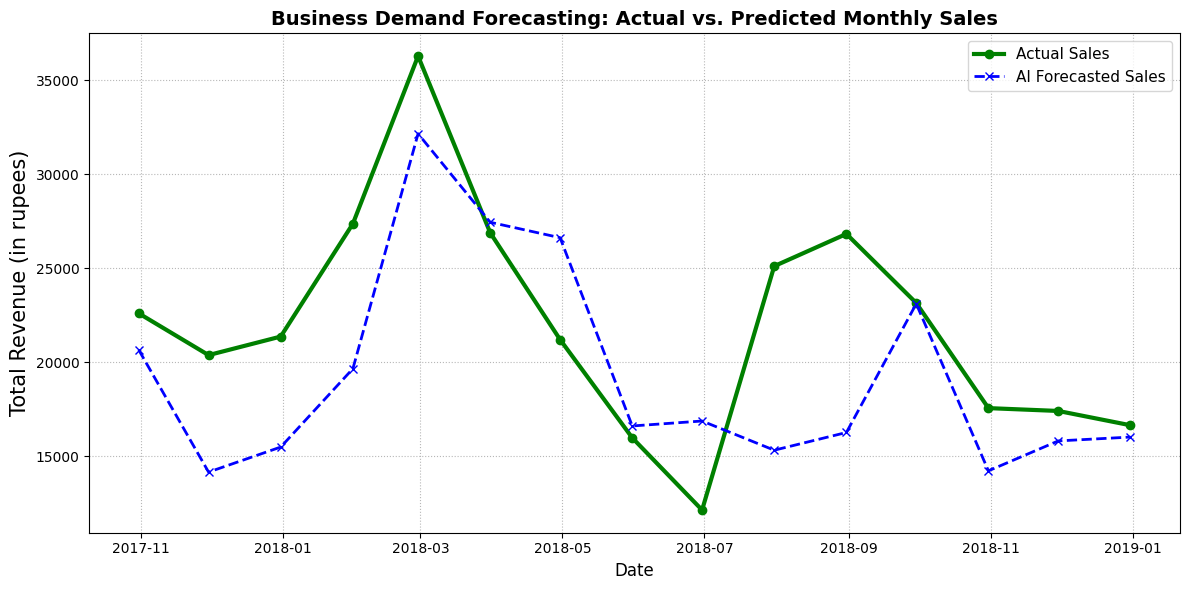

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. LOAD AND CLEAN DATA
# Fixed: Using 'latin1' encoding and ignoring unreadable special characters
df = pd.read_csv('sales_data.csv', encoding='latin1', encoding_errors='ignore')

# Convert the order date column to a standard datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date', 'Sales']).sort_values('Order Date')

# Group daily transactions into total monthly sales for smoother business forecasting
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

# 2. TIME-BASED FEATURE ENGINEERING
# Extract numerical features from dates so the machine learning algorithm can read them
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Time_Index'] = np.arange(len(monthly_sales))

# Create a "lag feature" (using the previous month's sales to predict the current month)
monthly_sales['Previous_Month_Sales'] = monthly_sales['Sales'].shift(1)
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

# 3. DEFINE FEATURES (X) AND TARGET (y)
X = monthly_sales[['Month', 'Year', 'Time_Index', 'Previous_Month_Sales']]
y = monthly_sales['Sales']

# Split data: 70% historical data for training the AI, 30% future data for testing accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

# 4. TRAIN THE FORECASTING MODEL
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. MODEL EVALUATION & ERROR ANALYSIS
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Model Evaluation Results:")
print(f"Mean Absolute Error (MAE): rupees {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): rupees {rmse:,.2f}")

# 6. BUSINESS-FRIENDLY VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Order Date'].iloc[-len(y_test):], y_test, label='Actual Sales', marker='o', color='green', linewidth=3)
plt.plot(monthly_sales['Order Date'].iloc[-len(y_test):], predictions, label='AI Forecasted Sales', marker='x', color='blue', linestyle='--', linewidth=2)
plt.title('Business Demand Forecasting: Actual vs. Predicted Monthly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue (in rupees)', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.9)
plt.tight_layout()

# Save the graph as an image to upload to GitHub
plt.savefig('sales_forecast_chart.png', dpi=300)
plt.show()